# 📈 Support Vector Regression (SVR)

## 🎯 Learning Objectives

After completing this notebook, you will be able to:

- Understand Support Vector Regression (SVR).
- Learn how SVR differs from Linear Regression.
- Understand the ε (epsilon) margin.
- Learn the role of kernels.
- Build an SVR model using Scikit-learn.
- Understand why feature scaling is required.

## 📖 Introduction

Support Vector Regression (SVR) is the regression version of Support Vector Machines (SVM).

Unlike Linear Regression, which tries to minimize the error for every point, SVR tries to fit a function where most data points lie within a specified margin called epsilon (ε).

Only the points outside this margin influence the model.

## ❓ What is Support Vector Regression?

SVR predicts continuous numerical values while allowing a small error (ε).

Instead of minimizing every error, it focuses on keeping predictions within an acceptable range.

Data points outside the epsilon margin are called Support Vectors and determine the final model.

## 🌍 Real-Life Intuition

Suppose a company predicts employee salaries.

Instead of trying to predict every salary exactly, it allows a small acceptable error (for example, ±₹5,000).

Only predictions that fall outside this acceptable range require adjustments.

This makes SVR more robust to small variations in the data.

## 📊 Linear Regression vs SVR

| Linear Regression | Support Vector Regression |
|-------------------|--------------------------|
| Minimizes error for all points | Uses an epsilon margin |
| Sensitive to outliers | More robust to small errors |
| No kernel | Supports kernels |
| Scaling not mandatory | Feature scaling is essential |

## 📚 Important Concepts

### Epsilon (ε)

The acceptable margin of error around the regression line.

---

### Support Vectors

Data points outside the epsilon margin that influence the model.

---

### Kernel

A mathematical function that enables SVR to model non-linear relationships.

## 🌐 Kernel Types

- Linear
- Polynomial
- RBF (Radial Basis Function) ⭐ Most commonly used
- Sigmoid

## ✅ Advantages

- Handles nonlinear relationships.
- Robust to small errors.
- Works well on small and medium-sized datasets.
- Flexible through kernel functions.

## ❌ Disadvantages

- Requires feature scaling.
- Slower on large datasets.
- Hyperparameter tuning can be challenging.

## 🌍 Applications

- Stock Price Prediction
- House Price Prediction
- Demand Forecasting
- Time Series Regression
- Engineering Problems

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [2]:
df = pd.read_csv("D:\Sanskruti\sanskruti document\Machine-Learning-From-Scratch\datasets\Position_Salaries.csv")

In [3]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [4]:
X = df[["Level"]].values
y = df["Salary"].values

In [5]:
sc_X = StandardScaler()
sc_y = StandardScaler()

X = sc_X.fit_transform(X)
y = sc_y.fit_transform(y.reshape(-1, 1)).ravel()

## Note: 
We scale both the features and the target because SVR is sensitive to the scale of the data.

In [6]:
model = SVR(
    kernel="rbf"
)

In [7]:
model.fit(X, y)

SVR()

In [8]:
scaled_prediction = model.predict(
    sc_X.transform([[6.5]])
)

salary = sc_y.inverse_transform(
    scaled_prediction.reshape(-1, 1)
)

print("Predicted Salary:", salary[0][0])

Predicted Salary: 170370.02040650236


C:\Users\Rushi\AppData\Local\Temp\ipykernel_30776\1598418834.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(


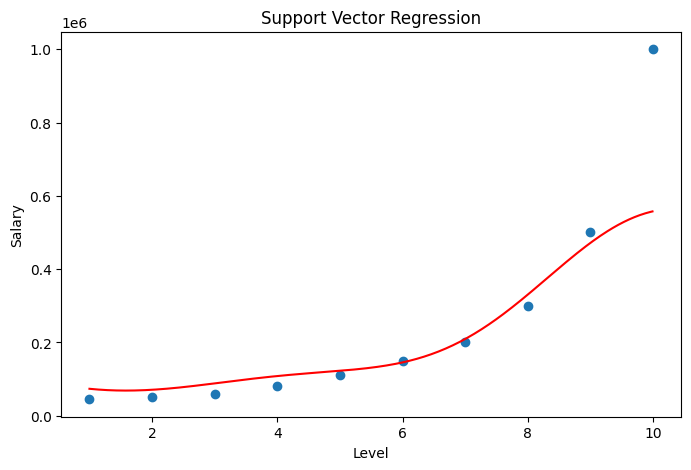

In [9]:
X_grid = np.arange(
    min(X),
    max(X),
    0.01
).reshape(-1, 1)

plt.figure(figsize=(8,5))

plt.scatter(
    sc_X.inverse_transform(X),
    sc_y.inverse_transform(y.reshape(-1,1))
)

plt.plot(
    sc_X.inverse_transform(X_grid),
    sc_y.inverse_transform(
        model.predict(X_grid).reshape(-1,1)
    ),
    color="red"
)

plt.title("Support Vector Regression")

plt.xlabel("Level")

plt.ylabel("Salary")

plt.show()

## ⚙️ Hyperparameters

### kernel

Type of kernel function.

---

### C

Controls the trade-off between model complexity and training error.

---

### epsilon

Defines the acceptable error margin.

---

### gamma

Controls the influence of individual training examples in RBF kernels.

## ⚠️ Common Mistakes

- Forgetting feature scaling.
- Choosing the wrong kernel.
- Using an unsuitable value for C or epsilon.
- Ignoring hyperparameter tuning.

## ✅ Best Practices

- Always scale features.
- Start with the RBF kernel.
- Tune C, gamma, and epsilon using cross-validation.
- Compare SVR with tree-based models on the same dataset.

## 📝 Summary

Support Vector Regression predicts continuous values while allowing a small acceptable error margin. By using support vectors and kernel functions, SVR can model both linear and nonlinear relationships effectively.